In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the primary training data
df_train = pd.read_csv('train.csv', parse_dates=['Date'], low_memory=False)
df_store = pd.read_csv('store.csv')

print(f"Training Data Shape: {df_train.shape}")
print(f"Store Metadata Shape: {df_store.shape}")

# 2. Look at the core features
print("\n--- Sales Data Columns ---")
print(df_train.columns.tolist())

print("\n--- Store Metadata Columns ---")
print(df_store.columns.tolist())

Training Data Shape: (1017209, 9)
Store Metadata Shape: (1115, 10)

--- Sales Data Columns ---
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

--- Store Metadata Columns ---
['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


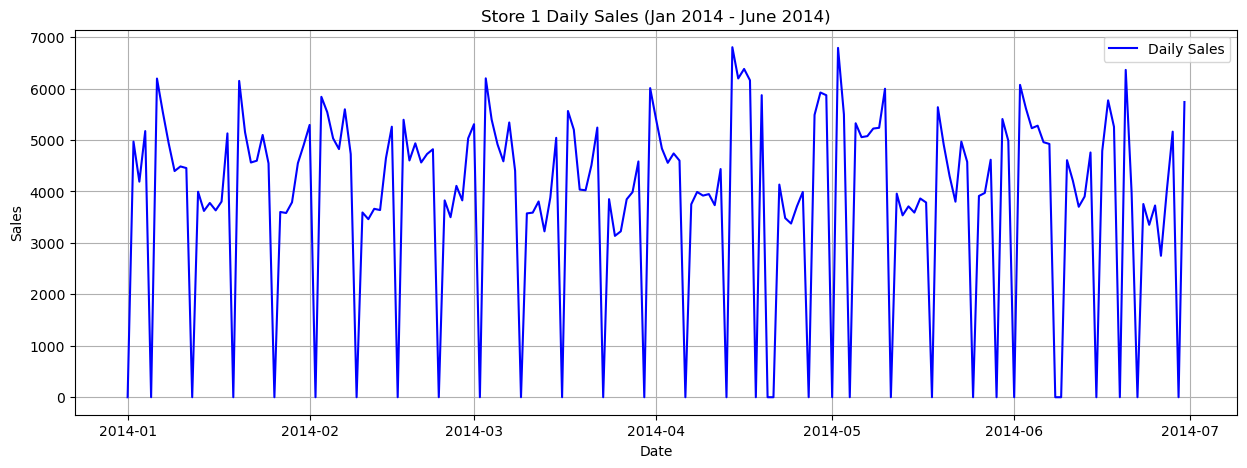

In [3]:
# Filter for Store 1 and sort chronologically
store_1 = df_train[df_train['Store'] == 1].sort_values('Date')

# Set Date as index for easier time-series slicing
store_1.set_index('Date', inplace=True)

# Plot a 6-month window to clearly see the patterns
plt.figure(figsize=(15, 5))
plt.plot(store_1.loc['2014-01-01':'2014-06-30', 'Sales'], label='Daily Sales', color='blue')
plt.title('Store 1 Daily Sales (Jan 2014 - June 2014)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.legend()
plt.show()

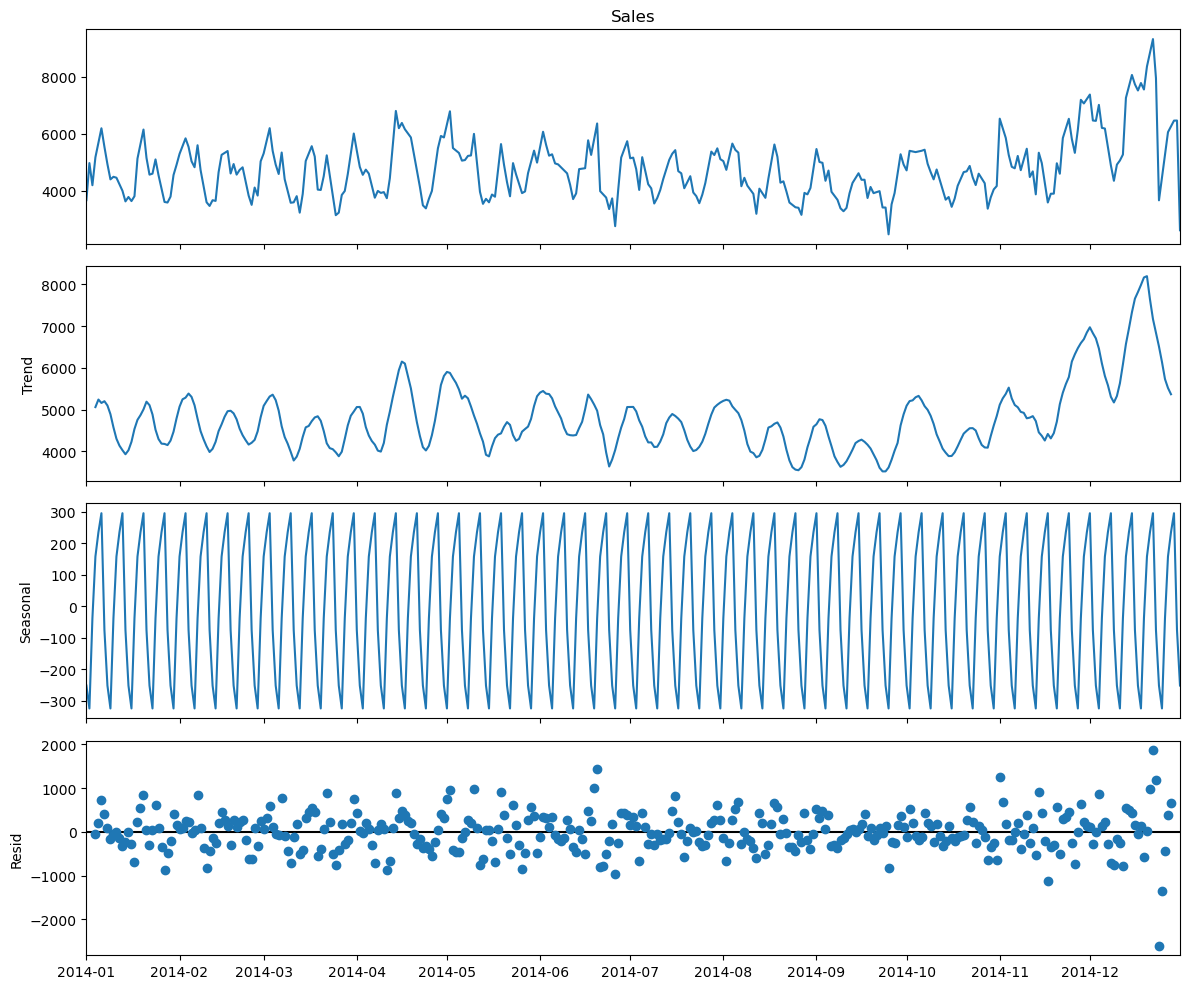

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Filter out days when the store was closed or had zero sales
store_1_open = store_1[store_1['Open'] != 0].copy()

# 2. Resample or ensure a clean, continuous daily frequency. 
# Since we removed Sundays, we will fill gaps linearly just for the mathematical decomposition plot
store_1_decomposition = store_1_open['Sales'].resample('D').interpolate(method='linear')

# 3. Perform Additive Decomposition (looking at a full year to capture seasonality)
# period=7 captures the weekly cycle
result = seasonal_decompose(store_1_decomposition.loc['2014-01-01':'2014-12-31'], model='additive', period=7)

# 4. Plot the separate components
plt.rc('figure', figsize=(12, 10))
result.plot()
plt.show()

In [5]:
# 1. Merge training data with store metadata on the 'Store' column
df_merged = pd.merge(df_train, df_store, on='Store', how='left')

print(f"Merged Dataset Shape: {df_merged.shape}")
print("\n--- New Engineered Feature Columns ---")
print(df_merged[['StoreType', 'Assortment', 'CompetitionDistance']].head())

# 2. Check for missing values in the merged metadata
print("\n--- Missing Values in Metadata ---")
print(df_merged[['CompetitionDistance', 'Promo2']].isnull().sum())

Merged Dataset Shape: (1017209, 18)

--- New Engineered Feature Columns ---
  StoreType Assortment  CompetitionDistance
0         c          a               1270.0
1         a          a                570.0
2         a          a              14130.0
3         c          c                620.0
4         a          a              29910.0

--- Missing Values in Metadata ---
CompetitionDistance    2642
Promo2                    0
dtype: int64


In [6]:
# 1. Inspect exact count of missing values in metadata columns
print("--- Missing Values Pre-Cleaning ---")
print(df_merged[['CompetitionDistance', 'CompetitionOpenSinceMonth', 'Promo2SinceYear']].isnull().sum())

# 2. Business Logic Imputation
# Logic A: If CompetitionDistance is missing, it likely means there is no competitor. 
# We replace it with a massive distance (e.g., max distance * 2, or a large constant like 100,000 meters).
max_dist = df_merged['CompetitionDistance'].max()
df_merged['CompetitionDistance'] = df_merged['CompetitionDistance'].fillna(max_dist * 2)

# Logic B: For missing dates/months of competitions and promotions, filling with 0 
# acts as an indicator variable telling the model "This event hasn't happened / doesn't exist".
df_merged['CompetitionOpenSinceMonth'] = df_merged['CompetitionOpenSinceMonth'].fillna(0)
df_merged['CompetitionOpenSinceYear'] = df_merged['CompetitionOpenSinceYear'].fillna(0)
df_merged['Promo2SinceWeek'] = df_merged['Promo2SinceWeek'].fillna(0)
df_merged['Promo2SinceYear'] = df_merged['Promo2SinceYear'].fillna(0)
df_merged['PromoInterval'] = df_merged['PromoInterval'].fillna("None")

print("\n--- Missing Values Post-Cleaning ---")
print(df_merged[['CompetitionDistance', 'CompetitionOpenSinceMonth', 'Promo2SinceYear']].isnull().sum())

--- Missing Values Pre-Cleaning ---
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
Promo2SinceYear              508031
dtype: int64

--- Missing Values Post-Cleaning ---
CompetitionDistance          0
CompetitionOpenSinceMonth    0
Promo2SinceYear              0
dtype: int64


In [7]:
# Extract key time attributes from the Date column
df_merged['Year'] = df_merged['Date'].dt.year
df_merged['Month'] = df_merged['Date'].dt.month
df_merged['Day'] = df_merged['Date'].dt.day
df_merged['DayOfWeek'] = df_merged['Date'].dt.dayofweek
df_merged['WeekOfYear'] = df_merged['Date'].dt.isocalendar().week.astype(int)

# Check our newly engineered columns
df_merged[['Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear']].head()

,Date,Year,Month,Day,DayOfWeek,WeekOfYear
0,2015-07-31,2015,7,31,4,31
1,2015-07-31,2015,7,31,4,31
2,2015-07-31,2015,7,31,4,31
3,2015-07-31,2015,7,31,4,31
4,2015-07-31,2015,7,31,4,31


In [8]:
# 1. Check the date boundaries of the dataset
print("Data starts at:", df_merged['Date'].min())
print("Data ends at:", df_merged['Date'].max())

# 2. Filter out days where the store was closed to keep training efficient
# (We handle closed days dynamically at the prediction phase)
df_open = df_merged[df_merged['Open'] != 0].copy()

# 3. Define the cut-off date for the final 6 weeks
# The dataset ends in late July 2015, so we cut off around mid-June 2015
cutoff_date = df_open['Date'].max() - pd.Timedelta(weeks=6)
print(f"Chronological Cut-off Date for Validation: {cutoff_date}")

# 4. Split into Train and Validation sets
train_set = df_open[df_open['Date'] <= cutoff_date].sort_values('Date')
val_set = df_open[df_open['Date'] > cutoff_date].sort_values('Date')

print(f"\nTrain Set Shape (Past): {train_set.shape} | Dates: {train_set['Date'].min()} to {train_set['Date'].max()}")
print(f"Validation Set Shape (Future): {val_set.shape} | Dates: {val_set['Date'].min()} to {val_set['Date'].max()}")

Data starts at: 2013-01-01 00:00:00
Data ends at: 2015-07-31 00:00:00
Chronological Cut-off Date for Validation: 2015-06-19 00:00:00

Train Set Shape (Past): (804110, 22) | Dates: 2013-01-01 00:00:00 to 2015-06-19 00:00:00
Validation Set Shape (Future): (40282, 22) | Dates: 2015-06-20 00:00:00 to 2015-07-31 00:00:00


In [12]:
from sklearn.preprocessing import LabelEncoder

# 1. Create a fresh copy of the datasets to prevent setting-with-copy warnings
train_cleaned = train_set.copy()
val_cleaned = val_set.copy()

# 2. Add 'PromoInterval' to our list of columns that need to be turned into numbers
categorical_cols = ['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval']

le = LabelEncoder()

# Apply encoding safely across train and validation data
for col in categorical_cols:
    # Convert everything to string first to handle any hidden mixed types cleanly
    train_cleaned[col] = le.fit_transform(train_cleaned[col].astype(str))
    val_cleaned[col] = le.transform(val_cleaned[col].astype(str))

# 3. Define features to drop (Target, leakage data, and original non-numeric dates)
drop_cols = ['Sales', 'Customers', 'Date']
feature_cols = [col for col in train_cleaned.columns if col not in drop_cols]

# 4. Rebuild the final feature and target matrices
X_train = train_cleaned[feature_cols]
y_train = train_cleaned['Sales']

X_val = val_cleaned[feature_cols]
y_val = val_cleaned['Sales']

print(f"Successfully processed {len(feature_cols)} numeric features!")
print("Categorical columns successfully encoded:", categorical_cols)

Successfully processed 19 numeric features!
Categorical columns successfully encoded: ['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval']


In [13]:
def rmspe(y_true, y_pred):
    # Avoid division by zero by ensuring y_true is not 0
    mask = y_true != 0
    return np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask])))

In [14]:
from sklearn.ensemble import RandomForestRegressor
import time

print("Starting Random Forest Training... This may take 1-2 minutes.")
start_time = time.time()

# 1. Initialize the regressor
# n_jobs=-1 tells computer to use all available CPU cores to speed up training
rf_forecast = RandomForestRegressor(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)

# 2. Fit the model
rf_forecast.fit(X_train, y_train)

print(f"Training completed in {time.time() - start_time:.2f} seconds!")

# 3. Predict on the validation set (the unseen 6 weeks of the future)
y_pred_val = rf_forecast.predict(X_val)

# 4. Calculate the baseline error
baseline_rmspe = rmspe(y_val.values, y_pred_val)
print(f"\n👉 Baseline Validation RMSPE: {baseline_rmspe:.4f}")

Starting Random Forest Training... This may take 1-2 minutes.
Training completed in 136.12 seconds!

👉 Baseline Validation RMSPE: 0.2393


In [16]:
# Initialize tuned XGBoost Regressor
xgb_tuned = xgb.XGBRegressor(
    n_estimators=150,
    max_depth=12,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

print("Training Tuned XGBoost... This might take a bit longer due to deeper trees.")
start_time = time.time()
xgb_tuned.fit(X_train, y_train)
print(f"Tuned XGBoost Training completed in {time.time() - start_time:.2f} seconds!")

# Predict and calculate new RMSPE
y_pred_xgb_tuned = xgb_tuned.predict(X_val)
tuned_xgb_rmspe = rmspe(y_val.values, y_pred_xgb_tuned)
print(f"\n👉 Tuned XGBoost Validation RMSPE: {tuned_xgb_rmspe:.4f}")

Training Tuned XGBoost... This might take a bit longer due to deeper trees.
Tuned XGBoost Training completed in 35.64 seconds!

👉 Tuned XGBoost Validation RMSPE: 0.1724


In [17]:
%pip install prophet


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------- ----------------------- 5.0/12.1 MB 26.8 MB/s eta 0:00:01
   ------------------------------------ --- 11.0/12.1 MB 27.6 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 25.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 19.0 MB/s eta 0:00:00

   -------- ------------------------------- 1/5 [importlib_resources]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   -

11:36:46 - cmdstanpy - INFO - Chain [1] start processing
11:36:47 - cmdstanpy - INFO - Chain [1] done processing



👉 Prophet Validation RMSPE for Store 1: 0.1717


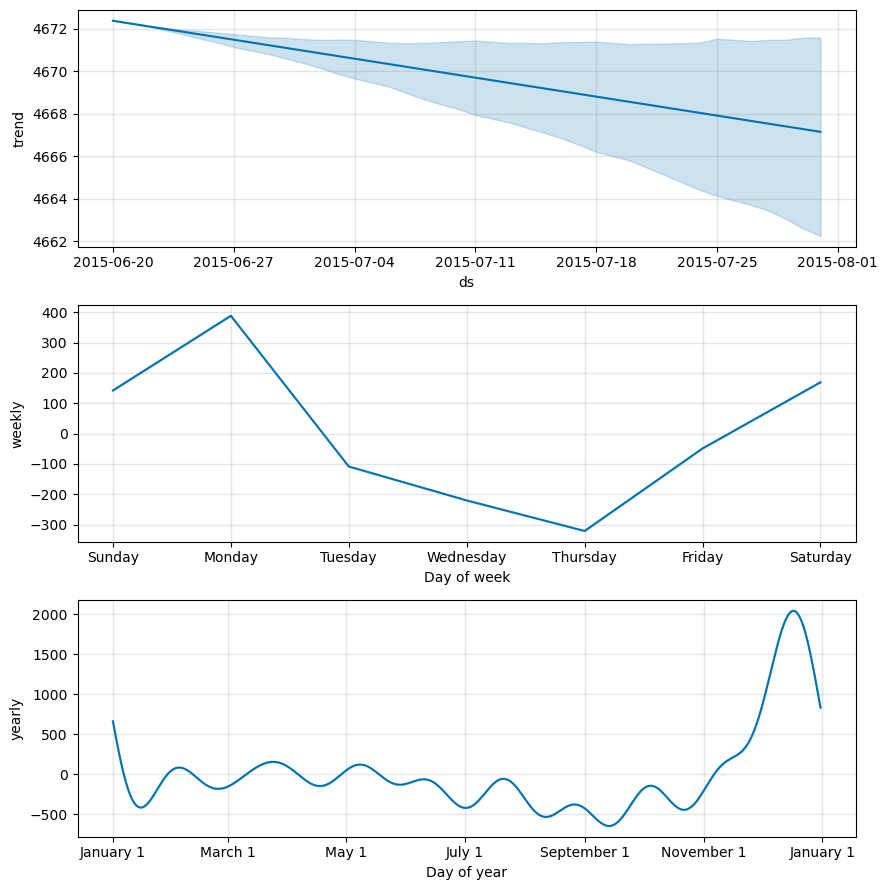

In [18]:
from prophet import Prophet

# 1. Prepare data for Store 1 (Prophet requires 'ds' and 'y' column names)
store_1_prophet = train_set[train_set['Store'] == 1][['Date', 'Sales']].copy()
store_1_prophet.rename(columns={'Date': 'ds', 'Sales': 'y'}, inplace=True)

# 2. Initialize and configure Prophet
# We explicitly turn on weekly and yearly seasonality
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95 # Generates a 95% confidence interval for inventory buffers
)

# 3. Fit the model
model_prophet.fit(store_1_prophet)

# 4. Create a future horizon dataframe for our 6-week validation window
validation_store_1 = val_set[val_set['Store'] == 1][['Date', 'Sales']].copy()
future_dates = validation_store_1[['Date']].rename(columns={'Date': 'ds'})

# 5. Predict the future
forecast = model_prophet.predict(future_dates)

# 6. Evaluate the performance using our custom RMSPE metric
prophet_pred = forecast['yhat'].values
prophet_actual = validation_store_1['Sales'].values
prophet_rmspe = rmspe(prophet_actual, prophet_pred)

print(f"\n👉 Prophet Validation RMSPE for Store 1: {prophet_rmspe:.4f}")

# 7. Plot the components (Trend, Weekly, Yearly patterns)
model_prophet.plot_components(forecast)
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_444\2615572825.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='magma')


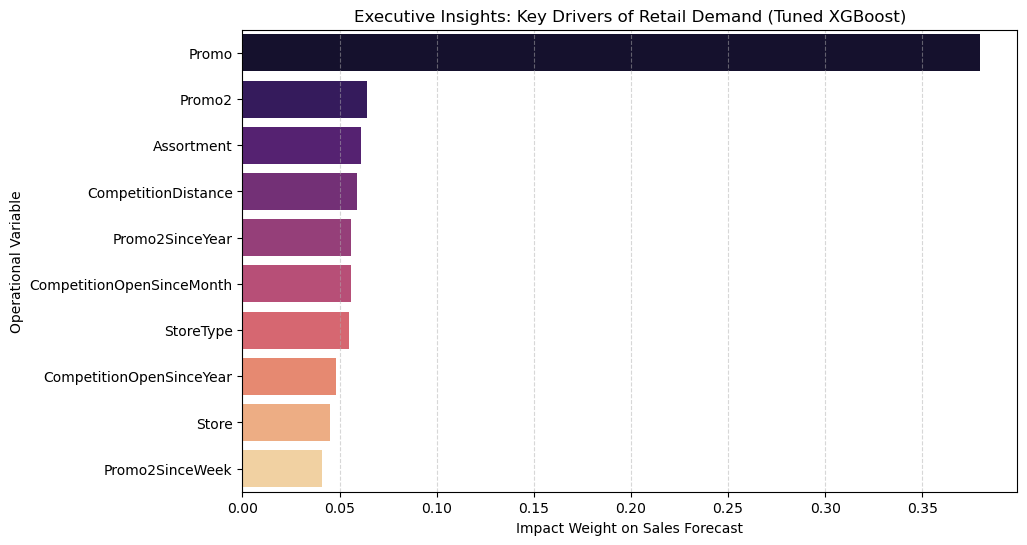

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Map feature importance weights from the tuned model
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

# 2. Render the executive dashboard plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='magma')
plt.title('Executive Insights: Key Drivers of Retail Demand (Tuned XGBoost)')
plt.xlabel('Impact Weight on Sales Forecast')
plt.ylabel('Operational Variable')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()